### Sistema Recomendación Híbrido

El objetivo de este proyecto es construir un sistema de recomendación basado en las compras realizadas por los clientes de una superficie comercial. El enfoque parte de una restricción clave: al tratarse de compra física, no es posible recomendar en tiempo real durante la compra, ya que no conocemos la cesta del cliente hasta que pasa por caja. Esto diferencia el problema del de una tienda online, donde sí se puede recomendar según la cesta se va componiendo.
Por ello, el sistema se orienta a la recomendación entre visitas: a partir del historial de compra de cada cliente, generar recomendaciones personalizadas que incentiven su siguiente visita (mediante email, app o cupones en el ticket), en línea con los programas de fidelización habituales en el sector.
Para ello se construyen tres modelos:

- ALS, que aprende los hábitos de cada cliente a partir de su historial para predecir y recomendar su próxima compra. Es el núcleo de la personalización.
- Apriori, que analiza la composición de las cestas para extraer patrones de co-compra. Más que recomendar al cliente directamente, alimenta decisiones de negocio: colocación de productos en tienda, promociones cruzadas y cupones post-compra.
- Popularidad, que recomienda los productos más vendidos como red de seguridad para clientes nuevos o sin historial suficiente.

En este notebook se construye el proceso de forma manual para entender el funcionamiento paso a paso. A mayores, los datos se encuentran poco diferenciados por lo que se han vuelto a generar los datos para trabajar con ellos en un notebook limpio donde los datos cuentan con patrones de diferenciación más marcados que nos permiten sacar un mejor rendimiento al sistema de recomendación. El motivo de volver a generar los datos no es tanto lograr mejores resultados en métricas sino lograr un factor de diferenciación entre los clientes y que las recomendaciones generadas tengan más sentido.

### Librerías

In [14]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

In [15]:
import pandas as pd
import numpy as np
from implicit.als import AlternatingLeastSquares
from scipy.sparse import csr_matrix
import optuna
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

In [16]:
df = pd.read_pickle('data/transacciones_limpio.pkl')

df.head(5)

,line_id,ticket_number,user_card_id,payment_method,shop_name,shop_address,product_code,product_name,seccion,units,price_per_unit,price_total,created_at
0,9526401,6567014,101629,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1063,HELADO CHOCOLATE 1L,Congelados,1,3.38,3.38,2025-01-01 08:20:00
1,9526398,6567014,101629,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1122,ACEITUNAS RELLENAS 350G,Snacks,3,1.77,5.31,2025-01-01 08:20:00
2,9526399,6567014,101629,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1123,PALOMITAS MICROONDAS PACK 3,Snacks,1,2.27,2.27,2025-01-01 08:20:00
3,9526400,6567014,101629,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1124,NACHOS 200G,Snacks,1,1.96,1.96,2025-01-01 08:20:00
4,9526403,6567014,101629,TARJETA,Carrefour A Coruña Marineda,"C/ Carretera Baños de Arteixo 43, A Coruña",1070,CROQUETAS JAMON 500G,Precocinados,2,3.17,6.34,2025-01-01 08:20:00


Comprobamos longitud datos y fecha mínima y máxima para realizar división de datos

In [17]:
print(f'Filas: {len(df):,}')
print(df.created_at.min())
print(df.created_at.max())

Filas: 100,000
2025-01-01 08:20:00
2025-06-30 21:58:00


Tras comprobar fechas procedemos a separar los datos y crear un conjunto de entrenamiento y testeo. Esta separación se realiza de forma manual.

In [18]:
# Fecha corte. Últimos 30 días para test
fecha_corte = df.created_at.max() - pd.Timedelta(days=30)
print(f'Fecha corte: {fecha_corte}')

# creamos conjuntos
train = df[df.created_at <= fecha_corte].copy()
test = df[df.created_at > fecha_corte].copy()

print(f'Longitud Train: {len(train)}; ({len(train)/len(df)*100:.0f}%)') 
print(f'Longitud Test: {len(test)}; ({len(test)/len(df)*100:.0f}%)')
print('-'*50)
print(f'Tickets train: {train.ticket_number.nunique():,}') # comprobación de tickets por conjunto
print(f'Tickets test: {test.ticket_number.nunique():,}')


Fecha corte: 2025-05-31 21:58:00
Longitud Train: 83443; (83%)
Longitud Test: 16557; (17%)
--------------------------------------------------
Tickets train: 7,944
Tickets test: 1,596


Ahora vamos a comprobar el número de clientes evaluables. Este paso es importante porque determina la frontera a partir de la cual entra en juego cada modelo. Para ALS, un sistema personalizado, se necesita un registro histórico del cliente por tanto no funcionará con aquellos clientes nuevos, lo que se conoce como cold start. Estos clientes nuevos, son aquellos que solo figuran en el conjunto de test y por tanto no tienen historial previo.

In [19]:
# almacenamos los clientes en conjuntos y eliminamos duplicados
clientes_train = set(train.user_card_id.unique())
clientes_test = set(test.user_card_id.unique())

evaluables = clientes_test & clientes_train # intersección que guarda solo clientes que se encuentran en ambos conjuntos. Aparecen tanto en train como test
cold_start = clientes_test - clientes_train  # clientes que compraron por primera vez dentro del rango de test.

print(f'Clientes en test: {len(clientes_test)}')
print(f'Evaluables: {len(evaluables)}') # clientes sobre los que se puede probar ALS
print(f'Cold start puro (test): {len(cold_start)}')

Clientes en test: 1083
Evaluables: 998
Cold start puro (test): 85


Con estos cálculos ya tenemos una idea sobre la cantidad de clientes que vamos a manejar en las evaluaciones de modelos.
Contamos con 1083 clientes dentro del conjunto de testeo de los cuales, 85 de ellos han realizado su primera compra en el periodo que contempla el conjunto de test. Los restantes 998 clientes se encuentran en ambos conjuntos y nos ayudarán a desarrollar ALS. 

### Modelo Basado en Popularidad

El primer modelo que se construye es un sistema NO personalizado. Este modelo solo se va a fijar en cuantas veces aparece cada producto en cada ticket. Se trata de un modelo totalmente sencillo que no necesita conocer ningún cliente, es ideal para cuando estamos empezando o el cliente es nuevo, se usa como referencia base.

In [20]:
# Popularidad de producto según tickets en conjunto train
popularidad = (
    train.groupby('product_name')['ticket_number']
    .nunique()
    .sort_values(ascending=False)
)

print('Top 10 productos más populares (por nº de tickets):')
print(popularidad.head(10))

Top 10 productos más populares (por nº de tickets):
product_name
MERMELADA FRESA 350G       5158
AZUCAR BLANCO 1KG          4307
CARNE PICADA MIXTA 500G    4164
CAFE MOLIDO 250G           3063
LECHE ENTERA BRIK 1L       3008
TOMATE FRITO 400G          2783
CEBOLLA KG                 2340
PATATA KG                  2253
PASTA ESPAGUETI 500G       2245
GALLETAS MARIA 800G        2204
Name: ticket_number, dtype: int64


In [21]:
def recomendar_popularidad(n=10):
    """
    Función para recomendar productos en base a la popularidad. Veces que aparece en tickets
    Parámetros:
    -n: número de productos seleccionados
    """
    return popularidad.head(n).index.tolist()

print(recomendar_popularidad(10))

['MERMELADA FRESA 350G', 'AZUCAR BLANCO 1KG', 'CARNE PICADA MIXTA 500G', 'CAFE MOLIDO 250G', 'LECHE ENTERA BRIK 1L', 'TOMATE FRITO 400G', 'CEBOLLA KG', 'PATATA KG', 'PASTA ESPAGUETI 500G', 'GALLETAS MARIA 800G']


Vamos a evaluar el comportamiento de este sistema base

In [22]:
recomendados = set(popularidad.head(10).index) # creamos un conjunto con los 10 productos más populares

# Comprobamos cliente de forma individual
cliente = list(evaluables)[0] # creamos una lista con los clientes y seleccionamos el primer cliente
comprados = set(test[test['user_card_id'] == cliente]['product_name']) # conjunto de productos comprados por el cliente dentro de test

print(f'Cliente: {cliente}')
print(f'Productos comprados en conjunto test: {len(comprados)}')
print(comprados)

Cliente: 100352
Productos comprados en conjunto test: 15
{'CARNE PICADA MIXTA 500G', 'PAN BARRA RUSTICA', 'HUEVOS DOCENA M', 'LENTEJAS PARDINA 1KG', 'CAFE MOLIDO 250G', 'TE VERDE 25 BOLSAS', 'TOMATE FRITO 400G', 'REFRESCO COLA 2L', 'AGUA MINERAL PACK 6', 'LECHE ENTERA BRIK 1L', 'MERMELADA FRESA 350G', 'CACAO SOLUBLE 800G', 'AZUCAR BLANCO 1KG', 'QUESO LONCHAS 200G', 'CEBOLLA KG'}


Guardamos en una variable los productos comprados por un cliente concreto durante el periodo de testeo. Ahora vamos a comparar este cliente con el top de productos más populares y ver la tasa de acierto.

In [23]:
aciertos = recomendados & comprados # creamos una intersección entre productos recomendados y comprados del cliente seleccionado

print(f'Nº de aciertos: {len(aciertos)}')
print(f'Aciertos: {aciertos}')

Nº de aciertos: 7
Aciertos: {'CARNE PICADA MIXTA 500G', 'CAFE MOLIDO 250G', 'TOMATE FRITO 400G', 'LECHE ENTERA BRIK 1L', 'MERMELADA FRESA 350G', 'AZUCAR BLANCO 1KG', 'CEBOLLA KG'}


De los 23 productos comprados por el cliente en el conjunto de test, 9 de ellos se encuentran dentro de los 10 más populares

In [24]:
precision = len(aciertos) / 10 # cuantos valores acertamos
recall = len(aciertos) / len(comprados) # de los productos comprados, cuantos cubrimos

print(f'Precision@10 para el cliente: {precision:.2f}')
print(f'Recall@10 para el cliente: {recall:.2f}')

Precision@10 para el cliente: 0.70
Recall@10 para el cliente: 0.47


La precision alta es esperable en un baseline de popularidad cuando los clientes consumen mayoritariamente productos populares. Por el contrario, el recall queda limitado de forma estructural, al recomendar solo 10 productos de 23 que compra este cliente, el valor máximo que se puede alcanzar es 0.43, siendo este resultado una métrica comparativa entre modelos.

In [25]:
# inicializamos lista para almacenar resultados de todos los clientes
precisiones = []
recalls = []

# inicializamos bucle
for c in evaluables:
    productos_comprados = set(test[test['user_card_id'] == c]['product_name'])

    productos_acertados = len(recomendados & productos_comprados) # intersección entre productos comprados y top 10 más populares.

    precisiones.append(productos_acertados/10) # añadimos la precision de cada cliente al listado
    recalls.append(productos_acertados/ len(productos_comprados)) # añadimos el recall de cada cliente al listado.

print(f'Cliente evaluados: {len(precisiones)}')
print(f'Precision@10 media : {np.mean(precisiones):.4f}')
print(f'Recall@10 media : {np.mean(recalls):.4f}')


Cliente evaluados: 998
Precision@10 media : 0.4695
Recall@10 media : 0.3712


Tras realizar el mecanismo de forma individual para un solo cliente, replicamos lo mismo en bucle para todos los clientes que aparecen en train y test. Esto devuelve una precision media de 0.5058, es decir, 5 de cada 10 productos recomendados acaban siendo compras reales del cliente. Se puede decir que es un buen resultado para un modelo NO personalizado.

En cuanto al Recall, este indica que los productos acertados representan el 45% de lo que el cliente compró.

El rendimiento del modelo no personalizado obtiene unos resultados muy buenos que pueden ser difíciles de superar para un modelo basado en ALS. El principal motivo de estos resultados es el propio dataset, no existe una gran diferenciación de clientes y el número de productos que se maneja es pequeño en comparación a un entorno real. Aunque se trate de datos sintéticos, esto no implica que en un entorno real, siempre vaya a tener mejor resultado un modelo más complejo como ALS, para una superficie tipo supermercado, recomendar simplemente los productos más vendidos puede ser más eficaz que tratar de construir un modelo más complejo.

In [26]:
pop_train = set(popularidad.head(10).index)
pop_test = set(test.groupby('product_name')['ticket_number'].nunique()
               .sort_values(ascending=False).head(10).index)

print(f'Productos en común entre top-10 train y top-10 test: {len(pop_train & pop_test)}/10')

Productos en común entre top-10 train y top-10 test: 10/10


Por último, comprobamos como de estable es el top 10 de productos entre train y test. El resultado que se obtiene es que 9 de cada 10 productos coinciden entre ambos conjuntos. (SUBIR ESTO ARRIBA TIENE MÁS SENTIDO)

### Sistema ALS

Mientras que el modelo basado en popularidad es un sistema no personalizado, el sistema ALS es un sistema de recomendación personalizado, en donde cada cliente recibe una recomendación acorde a su perfil.

El método Alternating Least Squares (ALS) consiste en crear una matriz cliente-producto en donde se registran las veces que cada cliente ha comprado cada producto. Esa matriz será la capa de entrada al modelo y donde empieza la factorización, partiendo de esta matriz ALS la descompone en dos matrices más pequeñas, una de clientes y otra de productos, descritas por factores latentes. Los factores latentes son características ocultas que el modelo inventa para explicar los datos. Este factor latente es similar a un ajuste de parámetros en ML clásico. 

Con esto, ALS congela una matriz mientras resuelve la otra y una vez tiene una resuelta, repite el proceso para la que aún no está resuelta apoyandose en la otra matriz. Una vez se ha completado este proceso, se realizan las prediciones que consiste en multiplicar los vecoters de factores. Si estos vectores están alineados, la predicción es alta y se devuelve la predicción más alta como recomendación.

La idea de seleccionar este método frente a otros se encuentra en que en un entorno real, la matriz de cliente-producto es muy dispersa y por tanto un sistema item-item tendrá complicaciones para realizar las recomendaciones. En este ejercicio la matriz con la que se trabaja no es dispersa.

In [27]:
# Frecuencia, nº de veces que cada cliente compró cada producto
interacciones = (train.groupby(['user_card_id', 'product_name'])
                 .size()
                 .reset_index(name='frecuencia'))

print(f'Interaciones cliente-producto: {len(interacciones)}')
interacciones.head()

Interaciones cliente-producto: 45987


,user_card_id,product_name,frecuencia
0,100001,AGUA CON GAS 1L,1
1,100001,AZUCAR BLANCO 1KG,1
2,100001,CAFE MOLIDO 250G,1
3,100001,CARNE PICADA MIXTA 500G,1
4,100001,CEBOLLA KG,1


Como la librería **implicit** trabaja con matrices donde filas y columnas son índices enteros hay que aplicar un mapeo.

In [28]:
# lista única productos y clientes
clientes_unicos = interacciones['user_card_id'].unique()
productos_unicos = interacciones['product_name'].unique()

# Mapeo
cliente_idx = {c: i for i, c in enumerate(clientes_unicos)} # compresión diccionario
productos_idx = {p: i for i, p in enumerate(productos_unicos)} # compresión diccionario

# Mapeo inverso; interpretación de resultados posterior
idx_cliente = {i: c for c, i in cliente_idx.items()}
idx_producto = {i: p for p, i in productos_idx.items()}

print(f'Clientes: {len(clientes_unicos)}')
print(f'Productos: {len(productos_unicos)}')


Clientes: 2197
Productos: 138


Una vez mapeados clientes y productos es hora de construir la matriz que recibe ALS. La matriz dispersa solo almacena las celdas que contienen valores ignorando aquellas que son cero. Para estos datos, tal vez no se aprecia su efecto, pero para grandes superficies supone una diferencia grande en cuanto a tiempo.

In [29]:
# Asignamos valores mapeados a cada valor.
filas = interacciones['user_card_id'].map(cliente_idx)
columnas = interacciones['product_name'].map(productos_idx)
valores = interacciones['frecuencia'].astype(float)

# Matriz dispersa cliente x producto
matriz_cp = csr_matrix(
    (valores, (filas,columnas)),
    shape=(len(clientes_unicos), len(productos_unicos))
)

print(f'Forma matriz: {matriz_cp.shape}')
print(f'Valores NO nulos: {matriz_cp.nnz:}')
print(f'Densidad: {matriz_cp.nnz / (matriz_cp.shape[0]*matriz_cp.shape[1])*100:.2f}%')

Forma matriz: (2197, 138)
Valores NO nulos: 45987
Densidad: 15.17%


Es importante tener en cuenta que se construye la matriz sobre el conjunto TRAIN por tanto el número de clientes se reduce ya que no todos los clientes de TRAIN se encuentran en TEST. Este método solo puede aprender con aquellos clientes que tienen historial, por tanto los nuevos clientes, los que se clasifican como cold start quedan fuera de este modelo.

Con la matriz creada vamos a iterar con ALS por primera vez, los valores que van a recibir los parámetros son los propios valores predeterminados que vienen con el modelo, sin ningún tipo de ajuste. Posteriormente se ajustarán estos parámetros mediante Optuna.

In [30]:
# modelo base
modelo_base_als = AlternatingLeastSquares(random_state=42)

modelo_base_als.fit(matriz_cp)
print('Modelo base entrenado')

c:\GitHUB\Portafolio-Data-Science-Python\SistemaRecomendacionHibrido\.venv\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

Modelo base entrenado


In [31]:
cliente_real = clientes_unicos[0] # ID real del cliente
cliente_index = cliente_idx[cliente_real] # indice en matriz

# Generación de recomendaciones
ids, scores = modelo_base_als.recommend(
    cliente_index,
    matriz_cp[cliente_index], # fila del cliente en matriz
    N=10, # top 10
    filter_already_liked_items=True # no recomendamos productos ya comprados
)

# Pasamos los índices de vuelta a nombres de producto
recomendaciones_als = [idx_producto[i] for i in ids]

print(f'Cliente: {cliente_real}')
print('Recomendaciones')
for prod, score in zip(recomendaciones_als, scores):
    print(f'{prod:35s} {score:.3f}')

Cliente: 100001
Recomendaciones
CEPILLO DENTAL PACK 2               0.157
GALLETAS CHOCOLATE 300G             0.139
CERVEZA PACK 6                      0.076
CHOCOLATE TABLETA 100G              0.076
PAPEL ALUMINIO 30M                  0.074
CHICLES PACK 3                      0.073
AMBIENTADOR HOGAR                   0.067
MARISCO CONGELADO 500G              0.066
GRANOLA BIO 400G                    0.058
ROLLO COCINA PACK 4                 0.055


In [32]:
print("\nLo que compró en train:")
set(train[train["user_card_id"] == cliente_real]["product_name"])


Lo que compró en train:


{'AGUA CON GAS 1L',
 'AZUCAR BLANCO 1KG',
 'CAFE MOLIDO 250G',
 'CARNE PICADA MIXTA 500G',
 'CEBOLLA KG',
 'ENSALADA CESAR PREPARADA',
 'GALLETAS MARIA 800G',
 'LECHE ENTERA BRIK 1L',
 'LECHUGA ICEBERG UD',
 'MANZANA GOLDEN KG',
 'MERMELADA FRESA 350G',
 'PASTA ESPAGUETI 500G',
 'PATATA KG',
 'PECHUGA POLLO BANDEJA',
 'QUESO LONCHAS 200G',
 'SALMON FRESCO KG',
 'TOMATE FRITO 400G',
 'ZANAHORIA KG'}

Observando las recomendaciones y puntuaciones que devuelve el modelo base con los productos que ha comprado en el conjunto train, se puede ver como el modelo base apenas está discriminando. Este es un resultado esperable ya que el modelo se encuentra sin ajustar y por tanto no puede encontrar factores latentes que hagan diferenciación de productos.

Ahora toca realizar la evaluación de resultados para este único cliente.

In [33]:
comprados_als_test = set(test[test['user_card_id'] == cliente_real]['product_name'])
print(f'Comprado en test ({len(comprados_als_test)} productos):')
print(comprados_als_test)

Comprado en test (0 productos):
set()


In [34]:
aciertos_als = set(recomendaciones_als) & comprados_als_test
precision_als = len(aciertos_als) / 10
recall_als = len(aciertos_als) / len(comprados_als_test) if len(comprados_als_test) > 0 else 0

print(f'Aciertos: {aciertos_als}')
print(f'Precision@10: {precision_als:.2f}')
print(f'Recall@10:    {recall_als:.2f}')

Aciertos: set()
Precision@10: 0.00
Recall@10:    0.00


In [35]:
print("RECOMENDADO por ALS:")
print(set(recomendaciones_als))
print()
print("COMPRADO en test:")
print(comprados_als_test)
print()
print("¿El cliente está en test?", cliente_real in test["user_card_id"].values)
print("Nº productos comprados en test:", len(comprados_als_test))

RECOMENDADO por ALS:
{'AMBIENTADOR HOGAR', 'GALLETAS CHOCOLATE 300G', 'GRANOLA BIO 400G', 'MARISCO CONGELADO 500G', 'CHICLES PACK 3', 'CERVEZA PACK 6', 'ROLLO COCINA PACK 4', 'PAPEL ALUMINIO 30M', 'CHOCOLATE TABLETA 100G', 'CEPILLO DENTAL PACK 2'}

COMPRADO en test:
set()

¿El cliente está en test? False
Nº productos comprados en test: 0


Teniendo en cuenta que se está evaluando con filtro activado, es decir, que no se recomienden productos ya comprados, para el cliente unitario donde se comprueba el sistema, el modelo base tiene nula capacidad de recomendación. Antes de pasar a un ajuste de modelo, se va a comprobar con todo el conjunto de clientes para ver los valores medios de evaluación.

In [36]:
# # inicializamos listas
# precisiones_als = []
# recalls_als = []

# for cliente in evaluables:
#     cliente_index = cliente_idx[cliente]

#     ids, scores = modelo_base_als.recommend(
#         cliente_index,
#         matriz_cp[cliente_index], # fila del cliente en matriz
#         N=10, # top 10
#         filter_already_liked_items=True # no recomendamos productos ya comprados
#     )

#     recomendados_als = set(idx_producto[i] for i in ids)
#     comprados_als = set(test[test['user_card_id'] == cliente]['product_name'])

#     if len(comprados_als) == 0:
#         continue

#     aciertos_als = len(recomendados_als & comprados_als)
#     precisiones_als.append(aciertos_als/10)
#     recalls_als.append(aciertos_als/len(comprados_als))

# print(f'Clientes evaluados: {len(precisiones_als)}')
# print(f'Precision@10: {np.mean(precisiones_als):.2f}')
# print(f'Recall@10:    {np.mean(recalls_als):.2f}')
    

Es importante tener en cuenta que sistema ALS para un tamaño de datos pequeño rara vez logrará batir a un sistema de recomendación. De hecho, en este momento, la comparación no es justa ya que el sistema ALS está excluyendo aquellos productos que ya han sido comprados por el cliente, es decir, busca en este momento descrubir productos nuevos que recomendar, una tarea que resulta complicada de por si. Por tanto el resultado a batir no son los resultados del sistema de popularidad, sino que se busca batir estos números del modelo base con el modelo optimizado.

Para evaluar con Optuna, vamos a crear una función con el código que ya hemos empleado en varias ocasiones.

In [37]:
def evaluar_als(modelo, matriz, clientes, k=10, filtrar=True):
    precisiones_als = []
    recalls_als = []

    for cliente in clientes:
        cliente_index = cliente_idx[cliente]

        ids, _ = modelo.recommend(
            cliente_index,
            matriz[cliente_index], # fila del cliente en matriz
            N=k, # top 10
            filter_already_liked_items=filtrar # no recomendamos productos ya comprados
        )

        recomendados_als = set(idx_producto[i] for i in ids)
        comprados_als = set(test[test['user_card_id'] == cliente]['product_name'])

        if len(comprados_als) == 0:
            continue

        aciertos_als = len(recomendados_als & comprados_als)
        precisiones_als.append(aciertos_als/k)
        recalls_als.append(aciertos_als/len(comprados_als))

    return np.mean(precisiones_als), np.mean(recalls_als)

La función nos devuelve la media de precision y recall calculada sobre cada cliente que es evaluable.

In [38]:
prec, rec = evaluar_als(modelo_base_als, matriz_cp, evaluables, k=10, filtrar=True)
print(f"Precision@10: {prec:.4f}  Recall@10: {rec:.4f}")

Precision@10: 0.0722  Recall@10: 0.0574


Con la función objetivo, se procede a realizar la búsqueda de los mejores parámetros para el modelo ALS, en este caso factores latentes.

- factors: es la opción más importante. Esto va indicar el número de dimensiones ocultas que el modelo va a usar para describir a clientes y productos. Cuantos más factores, mayor capacidad para capturar patrones complejos, pero nos arriesgamos a un sobreajuste
- regularization: se encarga de controlar el sobreajuste penalizando que los factores tomen valores demasiado grandes. Mismo concepto que Ridge, un valor alto fuerza al modelo a ser más conservador y un valor bajo da más libertad.
- alpha: es el factor de confianza y es específio en el feedback implícito. Al trabajar con frecuencias de compra, alpha se encarga de indicar cuanta confianza hay en esas frecuencias.
- iterations: indica el número de veces que hace el cálculo de cada matriz, es decir, el número de veces que refinamos el algoritmo.

In [39]:
def objetivo(trial):
    # Espacio de búsqueda
    factors = trial.suggest_int('factors', 5,100) # factores latentes
    regularization = trial.suggest_float('regularization', 0.001, 1.0, log=True) # regularización de sobreajuste
    alpha = trial.suggest_float('alpha', 1.0, 4.0) # confianza para feedback implícito
    iterations = trial.suggest_int('iterations', 10, 30) # iteracciones en matrices

    # Entrenar ALS
    modelo = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        alpha=alpha,
        iterations=iterations,
        random_state=42 # semilla para replicar resultados.
    )
    modelo.fit(matriz_cp)

    # Evaluación con filtro activado
    precision, _ = evaluar_als(modelo, matriz_cp, evaluables, k=10, filtrar=True)
    return precision

Una vez tenemos la función creada empezamos con el estudio.

In [40]:
study = optuna.create_study(direction='maximize')
study.optimize(objetivo, n_trials=30, show_progress_bar=False)

print('Mejor precision: ', study.best_value)
print('Mejores parámetros: ', study.best_params)

[I 2026-07-01 12:32:48,497] A new study created in memory with name: no-name-1bc9ebd4-f9b3-41de-a0ba-fbe8437ab383


  0%|          | 0/18 [00:00<?, ?it/s]

[I 2026-07-01 12:32:48,986] Trial 0 finished with value: 0.1497995991983968 and parameters: {'factors': 49, 'regularization': 0.044483831857385525, 'alpha': 2.9860681309627637, 'iterations': 18}. Best is trial 0 with value: 0.1497995991983968.


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-07-01 12:32:49,519] Trial 1 finished with value: 0.18657314629258517 and parameters: {'factors': 31, 'regularization': 0.026069824282528232, 'alpha': 1.6315057645978803, 'iterations': 25}. Best is trial 1 with value: 0.18657314629258517.


...

  0%|          | 0/16 [00:00<?, ?it/s]

[I 2026-07-01 12:33:01,530] Trial 28 finished with value: 0.1683366733466934 and parameters: {'factors': 39, 'regularization': 0.28942828233541795, 'alpha': 2.503603234628084, 'iterations': 16}. Best is trial 12 with value: 0.244188376753507.


  0%|          | 0/17 [00:00<?, ?it/s]

[I 2026-07-01 12:33:01,962] Trial 29 finished with value: 0.23557114228456916 and parameters: {'factors': 10, 'regularization': 0.039393437638666005, 'alpha': 2.8462906157227663, 'iterations': 17}. Best is trial 12 with value: 0.244188376753507.


Mejor precision:  0.244188376753507
Mejores parámetros:  {'factors': 6, 'regularization': 0.12958963496538145, 'alpha': 2.3360364943427134, 'iterations': 10}


Una vez se ha realizado el estudio y encontrado los mejores parámetros dentro de los rangos de búsqueda indicados, se procede a crear el modelo con esos parámetros y a entrenar.

In [41]:
modelo_als_final = AlternatingLeastSquares(**study.best_params, random_state=42)

modelo_als_final.fit(matriz_cp)

prec, rec = evaluar_als(modelo_als_final, matriz_cp, evaluables, k=10, filtrar=True)
print(f"Precision@10: {prec:.4f}  Recall@10: {rec:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

Precision@10: 0.2442  Recall@10: 0.1822


In [42]:
# Generamos recomendaciones para unos cuantos clientes y las inspeccionamos
for cliente_real in list(evaluables)[:5]:
    cliente_index = cliente_idx[cliente_real]
    
    ids, scores = modelo_als_final.recommend(
        cliente_index,
        matriz_cp[cliente_index],
        N=5,
        filter_already_liked_items=True
    )
    recomendados = [idx_producto[i] for i in ids]
    
    # Lo que el cliente compra habitualmente (train), para contexto
    compra_habitual = set(train[train["user_card_id"] == cliente_real]["product_name"])
    
    print(f"Cliente {cliente_real}")
    print(f"  Compra habitual: {list(compra_habitual)[:6]}")
    print(f"  Le recomendamos: {recomendados}")


Cliente 100352
  Compra habitual: ['CAFE MOLIDO 250G', 'TE VERDE 25 BOLSAS', 'TOMATE RAMA KG', 'LECHE ENTERA BRIK 1L', 'MERMELADA FRESA 350G', 'AZUCAR BLANCO 1KG']
  Le recomendamos: ['GALLETAS MARIA 800G', 'TOMATE FRITO 400G', 'CARNE PICADA MIXTA 500G', 'PASTA ESPAGUETI 500G', 'HARINA TRIGO 1KG']
Cliente 102402
  Compra habitual: ['REFRESCO COLA 2L', 'PALOMITAS MICROONDAS PACK 3', 'NACHOS 200G', 'PIZZA JAMON Y QUESO', 'ZUMO NARANJA 1L', 'WRAP POLLO PACK 2']
  Le recomendamos: ['CERVEZA PACK 6', 'ACEITUNAS RELLENAS 350G', 'HELADO CHOCOLATE 1L', 'EMPANADA ATUN', 'PIZZA CONGELADA 4 ESTACIONES']
Cliente 102403
  Compra habitual: ['PAN BARRA RUSTICA', 'MANZANA GOLDEN KG', 'LENTEJAS PARDINA 1KG', 'MACARRONES 500G', 'TOMATE FRITO 400G', 'BEBIDA SOJA 1L']
  Le recomendamos: ['PLATANO KG', 'GAMBA FRESCA KG', 'MERLUZA FILETE KG', 'FILETE TERNERA KG', 'CEREALES DESAYUNO 500G']
Cliente 102404
  Compra habitual: ['BEBIDA ENERGETICA 50CL', 'CERVEZA PACK 6', 'REFRESCO COLA 2L', 'PALOMITAS MICROONDAS

Para ver el comportamiento del modelo, se generan un par de recomendaciones comparando con la compra habitual del cliente. Los resultados que aporta el modelo, se pueden decir que son un poco lo esperado debido al resultado de las métricas. 

El cliente 100356, entre la compra habitual tiene leche y toallitas de bebe. Una recomendación realizada es leche infantil. Se puede decir que cumple la lógica esperada. 
Sin embargo, también se observa que hay ruido entre los resultados, en el cliente 100352 no hay un patrón de recomendación claro.

Lo más importante a tener en cuenta en esta situación, es que al ser datos sintéticos, no existe una gran diferenciación de clientes. Esto es observable en los resultados de las métricas. Ante la ausencia de diferenciación, en términos generales las recomendaciones no serán muy específicas.

### APRIORI

Como vamos a describir patrones de co-compra y no predecir, vamos a emplear el conjunto de datos completo. La idea de usar apriori es para desarrollar inteligencia de negocio. Que productos combinan entre ellos de forma complementaria buscando aumentar la cesta de la compra mediante cross-selling. Este conocimiento permite desarrollar una mejor distribución de la tienda y crear menos resistencia a los clientes para añadir productos complementarias a la cesta.

In [43]:
# Convertimos cada ticket en una lista de productos
cestas = df.groupby('ticket_number')['product_name'].apply(list)

print(f'Numero de cestas (tickets): {len(cestas)}')
print('Ejemplo de cesta')
print(cestas.iloc[0])

Numero de cestas (tickets): 9540
Ejemplo de cesta
['YOGUR NATURAL PACK 4', 'CEBOLLA KG', 'TOALLITAS BEBE PACK 3', 'LECHE INFANTIL CONTINUACION', 'PAPILLA CEREALES 600G', 'HUEVOS DOCENA M', 'POTITO FRUTA VARIADA', 'CHUPETE PACK 2', 'CARNE PICADA MIXTA 500G', 'MANTEQUILLA 250G']


El algoritmo Apriori trabaja con una matriz binaria, por tanto hay que aplicar un encoder que pase los datos a binario. El resultado que vamos a obtener es que cada fila es un ticket y cada columa un producto que recibe un valor True o False

In [44]:
te = TransactionEncoder() #instanciamos objeto
te_array = te.fit_transform(cestas)

# Pasamos array a DF
cestas_binarias = pd.DataFrame(te_array, columns=te.columns_)

print(f'Forma: {cestas_binarias.shape}')
cestas_binarias

Forma: (9540, 138)


,ACEITE OLIVA VIRGEN 1L,ACEITUNAS RELLENAS 350G,ACONDICIONADOR 400ML,AGUA CON GAS 1L,AGUA MINERAL PACK 6,AMBIENTADOR HOGAR,ARENA GATO 5L,ARROZ REDONDO 1KG,ATUN CLARO PACK 3,AZUCAR BLANCO 1KG,...,TORTILLA PATATA REFRIGERADA,VELAS AROMATICAS PACK 3,VERDURA WOK CONGELADA 750G,VINO BLANCO VERDEJO,VINO TINTO CRIANZA,WRAP POLLO PACK 2,YOGUR GRIEGO PACK 4,YOGUR NATURAL PACK 4,ZANAHORIA KG,ZUMO NARANJA 1L
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,True,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9535,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
9536,False,True,False,False,True,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
9537,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
9538,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Ahora con los datos transformados, es cuando se aplica Apriori para encontrar las combinaciones de productos que aparecen con frecuencia. En esta primera fase empleamos el primer parámetro de decisión, el soporte mínimo, que es el umbral de frecuencia que debe aparecer para cada combinación para ser considerada como una opción

In [45]:
# instanciamos algoritmo e indicamos que la frecuencia de aparición mínima sea un 2%
itemsets = apriori(cestas_binarias, min_support=0.02, use_colnames=True)

itemsets['longitud'] = itemsets['itemsets'].apply(len)

print(f'Itemsets encontados: {len(itemsets)}')
itemsets.sort_values('support', ascending=False).head(10)

Itemsets encontados: 12877


,support,itemsets,longitud
60,0.648952,frozenset({MERMELADA FRESA 350G}),1
7,0.542558,frozenset({AZUCAR BLANCO 1KG}),1
15,0.525157,frozenset({CARNE PICADA MIXTA 500G}),1
213,0.504822,"frozenset({AZUCAR BLANCO 1KG, MERMELADA FRESA ...",2
363,0.416457,"frozenset({CARNE PICADA MIXTA 500G, MERMELADA ...",2
13,0.384486,frozenset({CAFE MOLIDO 250G}),1
49,0.377883,frozenset({LECHE ENTERA BRIK 1L}),1
308,0.365409,"frozenset({MERMELADA FRESA 350G, CAFE MOLIDO 2...",2
188,0.361950,"frozenset({CARNE PICADA MIXTA 500G, AZUCAR BLA...",2
186,0.354822,"frozenset({AZUCAR BLANCO 1KG, CAFE MOLIDO 250G})",2


El valor de support que aparece en el DF creado indica la proporción con que aparece ese producto en los tickets. Para el champu anticaspa tenemos que aparece en el 78.4% de los tickets. Cuanto más alto sea ese valor, más común es esa combinación.

La longitud nos indica el número de productos que aparece en cada itemset. 
Para este ejercicio donde buscamos patrones de co-compra, los itemsets de longitud 1 no resultan interesantes, ya que muestran popularidad, no co-compra. Nos interesa encontrar productos complementarios.

Con esto presente, vamos a generar reglas de asocicación.

In [46]:
# regla de asociacion con lift
reglas = association_rules(itemsets, metric='lift', min_threshold=1)

print(f'Reglas generadas: {len(reglas)}')
print(reglas.columns.tolist())

Reglas generadas: 469562
['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'representativity', 'leverage', 'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski']


Con un soporte mínimo del 2% se crean demasiadas reglas, 171158, lo que resulta completamente inmanejable. El umbral aquí no es una decisión optimizable, es una decisión de negocio. Para poder visualizar esta situación, vamos a dejar este código como base y subir el umbral en otro bloque.

In [47]:
# Reglas accionables: combinaciones frecuentes Y con asociación fuerte
reglas_filtradas = reglas[
    (reglas["support"] >= 0.05) &      # aparece en al menos 5% de cestas
    (reglas["lift"] >= 1.2) &          # asociación notablemente sobre el azar
    (reglas["confidence"] >= 0.5)      # quien compra A, al menos 50% compra B
].sort_values("lift", ascending=False)

print(f"Reglas tras filtrar: {len(reglas_filtradas)}")
reglas_filtradas[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

Reglas tras filtrar: 12448


,antecedents,consequents,support,confidence,lift
11570,frozenset({LECHE AVENA 1L}),"frozenset({MERMELADA FRESA 350G, HAMBURGUESA V...",0.054088,0.844517,10.198347
11567,"frozenset({MERMELADA FRESA 350G, HAMBURGUESA V...",frozenset({LECHE AVENA 1L}),0.054088,0.653165,10.198347
7755,frozenset({HAMBURGUESA VEGETAL PACK 2}),"frozenset({CARNE PICADA MIXTA 500G, LECHE AVEN...",0.050000,0.561837,10.170644
7750,"frozenset({CARNE PICADA MIXTA 500G, LECHE AVEN...",frozenset({HAMBURGUESA VEGETAL PACK 2}),0.050000,0.905123,10.170644
7751,"frozenset({CARNE PICADA MIXTA 500G, HAMBURGUES...",frozenset({LECHE AVENA 1L}),0.050000,0.648098,10.119236
7754,frozenset({LECHE AVENA 1L}),"frozenset({CARNE PICADA MIXTA 500G, HAMBURGUES...",0.050000,0.780687,10.119236
11566,"frozenset({MERMELADA FRESA 350G, LECHE AVENA 1L})",frozenset({HAMBURGUESA VEGETAL PACK 2}),0.054088,0.898955,10.101328
11571,frozenset({HAMBURGUESA VEGETAL PACK 2}),"frozenset({MERMELADA FRESA 350G, LECHE AVENA 1L})",0.054088,0.607774,10.101328
927,frozenset({HAMBURGUESA VEGETAL PACK 2}),frozenset({LECHE AVENA 1L}),0.056918,0.639576,9.986178
926,frozenset({LECHE AVENA 1L}),frozenset({HAMBURGUESA VEGETAL PACK 2}),0.056918,0.888707,9.986178


In [51]:
# Nos quedamos con las reglas más fuertes y las simplificamos a 1→1 producto
reglas_top = reglas[
    (reglas["antecedents"].apply(len) == 1) &
    (reglas["consequents"].apply(len) == 1) &
    (reglas["lift"] >= 1.5)
].copy()

# Convertimos los frozensets a strings legibles
reglas_top["antecedente"] = reglas_top["antecedents"].apply(lambda x: list(x)[0])
reglas_top["consecuente"] = reglas_top["consequents"].apply(lambda x: list(x)[0])

reglas_top = reglas_top.sort_values("lift", ascending=False)
print(f"Reglas seleccionadas: {len(reglas_top)}")
reglas_top[["antecedente", "consecuente", "support", "confidence", "lift"]]

Reglas seleccionadas: 1024


,antecedente,consecuente,support,confidence,lift
1397,SNACKS PERRO 200G,PIENSO PERRO 4KG,0.031551,0.817935,16.963256
1396,PIENSO PERRO 4KG,SNACKS PERRO 200G,0.031551,0.654348,16.963256
731,CREMA PAÑAL 100ML,PAÑALES T4 PACK 44,0.029140,0.605664,16.747940
730,PAÑALES T4 PACK 44,CREMA PAÑAL 100ML,0.029140,0.805797,16.747940
1443,TOFU NATURAL 250G,QUINOA 500G,0.029769,0.616052,15.147259
...,...,...,...,...,...
1044,PATATA KG,LECHE ENTERA BRIK 1L,0.161635,0.567956,1.502995
312,MERMELADA FRESA 350G,CACAO SOLUBLE 800G,0.037317,0.057503,1.502951
313,CACAO SOLUBLE 800G,MERMELADA FRESA 350G,0.037317,0.975342,1.502951
124,ATUN CLARO PACK 3,MERMELADA FRESA 350G,0.034591,0.973451,1.500036


Una vez creadas las reglas de negocio, procedemos a graficar las asociaciones. Para graficar las asociaciones se construyen grafos. Se van a crear dos gráficos, uno estático en donde se visualiza en el propio notebook y otro dinámico que se visualiza mediante HTML y es más vistoso.

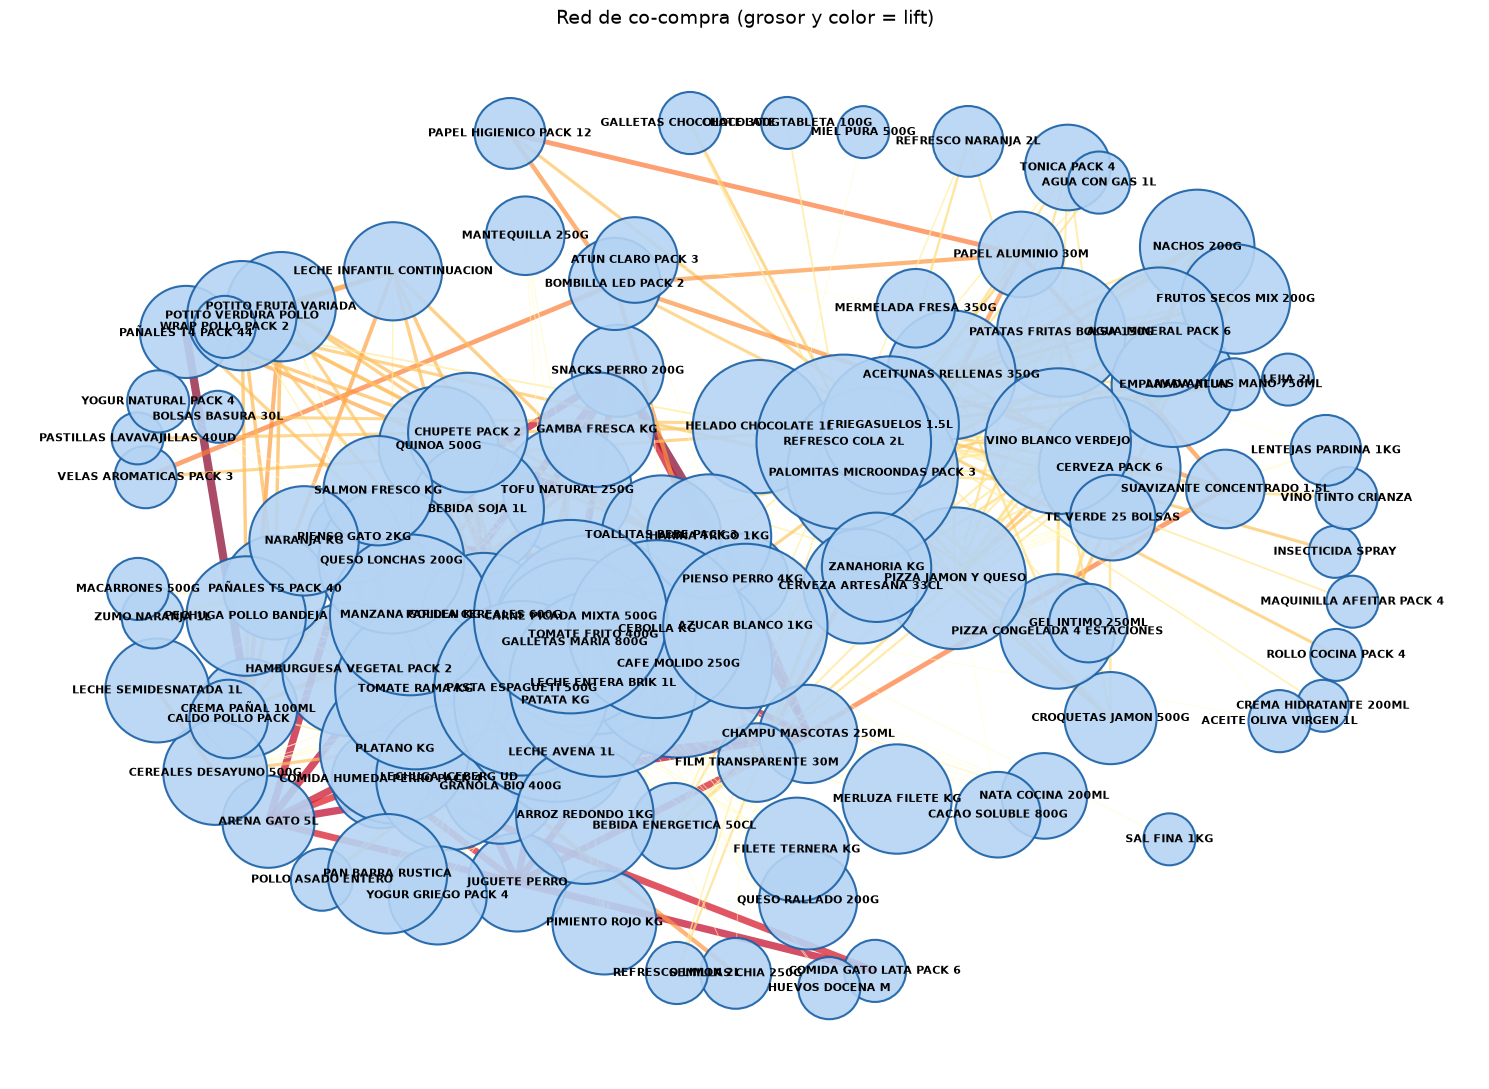

In [52]:


G = nx.from_pandas_edgelist(
    reglas_top, source="antecedente", target="consecuente",
    edge_attr="lift", create_using=nx.Graph()   # Graph, no DiGraph: evita flechas dobles
)

# Layout más compacto
pos = nx.spring_layout(G, k=1.8, iterations=100, seed=42)

fig, ax = plt.subplots(figsize=(15, 11))

lifts = [G[u][v]["lift"] for u, v in G.edges()]
anchos = [l / max(lifts) * 6 for l in lifts]

# Tamaño de nodo según sus conexiones (grado)
grados = dict(G.degree())
tam = [800 + grados[n] * 600 for n in G.nodes()]

nx.draw_networkx_edges(G, pos, width=anchos, edge_color=lifts,
                       edge_cmap=plt.cm.YlOrRd, alpha=0.7, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=tam, node_color="#B5D4F4",
                       edgecolors="#185FA5", linewidths=1.5, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)

ax.set_title("Red de co-compra (grosor y color = lift)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

In [53]:


# Primero detectamos los clusters automáticamente con networkx
G = nx.from_pandas_edgelist(reglas_top, "antecedente", "consecuente", edge_attr="lift")
comunidades = nx.community.greedy_modularity_communities(G)

# Asignamos un color a cada cluster
paleta = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD", "#EF9F27",
          "#D4537E", "#639922", "#E24B4A"]
color_nodo = {}
for i, comunidad in enumerate(comunidades):
    for producto in comunidad:
        color_nodo[producto] = paleta[i % len(paleta)]

# Construimos la red con esos colores
net = Network(height="650px", width="100%", bgcolor="#ffffff", font_color="#333333")

for _, fila in reglas_top.iterrows():
    ant, con, lift = fila["antecedente"], fila["consecuente"], fila["lift"]
    net.add_node(ant, label=ant, color=color_nodo.get(ant, "#B5D4F4"),
                 size=20, title=ant)
    net.add_node(con, label=con, color=color_nodo.get(con, "#B5D4F4"),
                 size=20, title=con)
    # Color de arista según lift: más intenso = más fuerte
    intensidad = int(min(lift / reglas_top["lift"].max() * 255, 255))
    color_arista = f"#{255-intensidad:02x}{100:02x}{intensidad:02x}"
    net.add_edge(ant, con, value=float(lift),
                 title=f"Lift: {lift:.2f}", color=color_arista)

net.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=150)
net.save_graph("red_cocompra_color.html")
print("Guardado red_cocompra_color.html")

Guardado red_cocompra_color.html
